In [2]:
# Bonus Analysis — Hamzah Alssoudi
# Territories: Maryland (Shruti Reddy) & Massachusetts (Bo Heap), both Northeast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 6)

# Load data
sales = pd.read_csv('StoreSales.csv')
stores = pd.read_csv('StoreDetail.csv')
products = pd.read_csv('Products.csv')
categories = pd.read_csv('ProductCategories.csv')
customers = pd.read_csv('customer_list.csv', sep='|')
customers.columns = customers.columns.str.strip()

# Clean
sales['Transaction Date'] = pd.to_datetime(sales['Transaction Date'], format='%m/%d/%Y')
sales['Month'] = sales['Transaction Date'].dt.to_period('M')
sales['Year'] = sales['Transaction Date'].dt.year

# Fix duplicate category key
categories.loc[categories['SubcategoryID'] == '115-pai', 'Subcategory'] = 'Paints & Brushes'
categories = categories.drop_duplicates(['CategoryID', 'SubcategoryID']).reset_index(drop=True)

# Master merged table
df = (sales.merge(stores, on='Store ID', how='left')
           .merge(products, on='Prod Num', how='left')
           .merge(categories, on=['CategoryID', 'SubcategoryID'], how='left'))
df.loc[df['Category'].isna(), ['Category', 'Subcategory']] = ['Art Supplies', 'Adhesives']

# Territory subset
MY_STATES = ['Maryland', 'Massachusetts']
terr = df[df['State'].isin(MY_STATES)].copy()

print("Full dataset:", len(df), "transactions | My territories:", len(terr))

Full dataset: 335129 transactions | My territories: 131476


In [3]:
# Q1: List January 2024 transactions sorted highest to lowest. Which are > $500?

jan24 = (df[(df['Year'] == 2024) & (df['Transaction Date'].dt.month == 1)]
         .sort_values('Sale Amount', ascending=False)
         [['Transaction Date', 'Store Location', 'State', 'Prod Num', 'Product', 'Sale Amount']])
print("Total January 2024 transactions:", len(jan24))
jan24.head(10)

Total January 2024 transactions: 6654


,Transaction Date,Store Location,State,Prod Num,Product,Sale Amount
133164,2024-01-01,Orlando,Florida,105341-IT,MSI Creator Z16,1763.7
139709,2024-01-31,Orono,Maine,105341-IT,MSI Creator Z16,1763.7
136870,2024-01-18,North Harford,Maryland,105341-IT,MSI Creator Z16,1763.7
135291,2024-01-10,South Portland,Maine,105341-IT,MSI Creator Z16,1763.7
138720,2024-01-27,Aurora,Colorado,105341-IT,MSI Creator Z16,1763.7
135133,2024-01-09,Waterbury,Connecticut,105341-IT,MSI Creator Z16,1763.7
134987,2024-01-09,Annapolis,Maryland,105341-IT,MSI Creator Z16,1763.7
138780,2024-01-27,North Harford,Maryland,105341-IT,MSI Creator Z16,1763.7
139613,2024-01-31,Tampa,Florida,105326-IT,"Apple MacBook Air (M2, 13-inch)",1717.7
135160,2024-01-10,Denver,Colorado,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1717.7


In [4]:
over_500 = jan24[jan24['Sale Amount'] > 500]
print("January 2024 transactions over $500:", len(over_500))
over_500.head(10)

January 2024 transactions over $500: 497


,Transaction Date,Store Location,State,Prod Num,Product,Sale Amount
133164,2024-01-01,Orlando,Florida,105341-IT,MSI Creator Z16,1763.7
139709,2024-01-31,Orono,Maine,105341-IT,MSI Creator Z16,1763.7
136870,2024-01-18,North Harford,Maryland,105341-IT,MSI Creator Z16,1763.7
135291,2024-01-10,South Portland,Maine,105341-IT,MSI Creator Z16,1763.7
138720,2024-01-27,Aurora,Colorado,105341-IT,MSI Creator Z16,1763.7
135133,2024-01-09,Waterbury,Connecticut,105341-IT,MSI Creator Z16,1763.7
134987,2024-01-09,Annapolis,Maryland,105341-IT,MSI Creator Z16,1763.7
138780,2024-01-27,North Harford,Maryland,105341-IT,MSI Creator Z16,1763.7
139613,2024-01-31,Tampa,Florida,105326-IT,"Apple MacBook Air (M2, 13-inch)",1717.7
135160,2024-01-10,Denver,Colorado,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1717.7


In [5]:
# Q2: Products whose product number begins with '10525'. What category/subcategory?

p10525 = products[products['Prod Num'].str.startswith('10525')].merge(
    categories, on=['CategoryID', 'SubcategoryID'], how='left')
p10525[['Prod Num', 'Product', 'Category', 'Subcategory']]

,Prod Num,Product,Category,Subcategory
0,105250-IT,Realme Pad,Technology & Accessories,Tablets
1,105251-IT,Lenovo Tab P12 Pro,Technology & Accessories,Tablets
2,105252-IT,Microsoft Surface Pro 9,Technology & Accessories,Tablets
3,105253-IT,"Apple iPad Pro (12.9-inch, M2)",Technology & Accessories,Tablets
4,105254-IT,Chuwi HiPad Max,Technology & Accessories,Tablets
5,105255-IT,Lenovo Yoga Smart Tab,Technology & Accessories,Tablets
6,105256-IT,ASUS Vivobook 13 Slate OLED,Technology & Accessories,Tablets
7,105257-IT,Samsung Galaxy Tab S9 Ultra,Technology & Accessories,Tablets
8,105258-IT,Apple iPad Air (10.9-inch),Technology & Accessories,Tablets
9,105259-IT,Teclast T40 Pro,Technology & Accessories,Tablets


In [6]:
# Q3: Stores in my territories with at least one sale over $1,000. How many such transactions?

big = terr[terr['Sale Amount'] > 1000]
big_by_store = (big.groupby(['State', 'Store Location'])
                .size().rename('Txns_over_1000')
                .sort_values(ascending=False).reset_index())
print("Stores in my territories with a transaction over $1,000:", len(big_by_store))
big_by_store

Stores in my territories with a transaction over $1,000: 27


,State,Store Location,Txns_over_1000
0,Maryland,North Harford,2241
1,Massachusetts,Worcester,163
2,Maryland,Germantown,153
3,Massachusetts,Leominster,107
4,Massachusetts,Nantucket,98
5,Massachusetts,Somerville,96
6,Massachusetts,Holyoke,95
7,Massachusetts,Provincetown,94
8,Massachusetts,Northampton,91
9,Maryland,Parkville,91


In [7]:
# Q4: Total revenue across all in-store transactions. Average transaction. Standard deviation.

amounts = df['Sale Amount'].to_numpy()
print(f"Total sales revenue:      ${amounts.sum():,.2f}")
print(f"Average transaction:      ${np.mean(amounts):,.2f}")
print(f"Standard deviation:       ${np.std(amounts):,.2f}")
print(f"Number of transactions:   {len(amounts):,}")

Total sales revenue:      $45,370,048.85
Average transaction:      $135.38
Standard deviation:       $279.72
Number of transactions:   335,129


In [8]:
# Q5: Which stores had total revenue ABOVE the average store revenue across the full dataset?
# (Hint: use np.mean().)

store_totals = df.groupby(['Store ID', 'Store Location', 'State'])['Sale Amount'].sum()
avg_store_rev = np.mean(store_totals.to_numpy())
print(f"Average store revenue across all {len(store_totals)} stores: ${avg_store_rev:,.2f}\n")

above_avg = (store_totals[store_totals > avg_store_rev]
             .sort_values(ascending=False).round(2).reset_index())
above_avg.columns = ['Store ID', 'Store Location', 'State', 'Total_Revenue']
print(f"Stores above average: {len(above_avg)} of {len(store_totals)}")
above_avg.head(15)

Average store revenue across all 111 stores: $408,739.18

Stores above average: 12 of 111


,Store ID,Store Location,State,Total_Revenue
0,736,North Harford,Maryland,8708119.00
1,705,Denver,Colorado,917471.53
2,709,Greeley,Colorado,640368.11
3,905,Beaumont,Texas,637818.90
4,835,Newark,New Jersey,623163.53
5,850,New York,New York,621565.02
6,724,Miami,Florida,618846.25
7,847,Rochester,New York,607148.21
8,817,Worcester,Massachusetts,602183.44
9,838,Trenton,New Jersey,597565.68


In [9]:
# Q6: Total revenue by product category across all territories, sorted. Most transactions?

cat_summary = (df.groupby('Category')
               .agg(Total_Revenue=('Sale Amount', 'sum'),
                    Transactions=('Sale Amount', 'count'))
               .sort_values('Total_Revenue', ascending=False).round(2))
cat_summary

,Total_Revenue,Transactions
Category,,
Technology & Accessories,31891406.58,68344
Textbooks,7961357.21,45924
Apparel and Merchandise,2043382.60,63346
Art Supplies,1701095.43,53143
Books (General),1070718.51,35196
Stationery and Supplies,702088.52,69176


In [10]:
print("Highest revenue category: ", cat_summary['Total_Revenue'].idxmax())
print("Most transactions category:", cat_summary['Transactions'].idxmax())

Highest revenue category:  Technology & Accessories
Most transactions category: Stationery and Supplies


In [11]:
# Q7: Top 10 best-selling individual products by total revenue (full dataset).

top10_products = (df.groupby(['Prod Num', 'Product'])['Sale Amount']
                  .sum().sort_values(ascending=False).head(10).round(2).reset_index())
top10_products.columns = ['Prod Num', 'Product', 'Total_Revenue']
top10_products

,Prod Num,Product,Total_Revenue
0,105341-IT,MSI Creator Z16,1199316.00
1,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1082151.00
2,105326-IT,"Apple MacBook Air (M2, 13-inch)",1003136.80
3,105337-IT,HP Pavilion 14,913919.76
4,105333-IT,ASUS VivoBook S15,900524.00
5,105334-IT,Samsung Galaxy Book Pro,890257.12
6,105324-IT,Lenovo IdeaPad Flex 5,877535.40
7,105330-IT,LG Gram 17,876792.28
8,105332-IT,HP Spectre x360,874421.04
9,105331-IT,Acer Chromebook Spin 713,872358.20


In [12]:
# Q8: For each transaction in my territories: date, sale amount, city, state, territory manager.
# (Requires merging StoreSales with StoreDetail.)

terr_detail = (sales[sales['Store ID'].isin(
                  stores[stores['State'].isin(MY_STATES)]['Store ID'])]
               .merge(stores, on='Store ID', how='left')
               [['Transaction Date', 'Sale Amount', 'Store Location',
                 'State', 'Territory Manager']]
               .rename(columns={'Store Location': 'City'}))
print("Transactions in my territories:", len(terr_detail))
terr_detail.head(10)

Transactions in my territories: 131476


,Transaction Date,Sale Amount,City,State,Territory Manager
0,2022-01-01,23.44,Annapolis,Maryland,Shruti Reddy
1,2022-01-01,27.52,Baltimore,Maryland,Shruti Reddy
2,2022-01-01,25.00,Germantown,Maryland,Shruti Reddy
3,2022-01-01,8.00,Howard,Maryland,Shruti Reddy
4,2022-01-01,71.74,North Harford,Maryland,Shruti Reddy
5,2022-01-01,1717.70,North Harford,Maryland,Shruti Reddy
6,2022-01-01,69.90,North Harford,Maryland,Shruti Reddy
7,2022-01-01,237.28,North Harford,Maryland,Shruti Reddy
8,2022-01-01,76.86,North Harford,Maryland,Shruti Reddy
9,2022-01-01,126.18,North Harford,Maryland,Shruti Reddy


In [13]:
# Q9: Total revenue by region across the full dataset. Which region generates the most?

region_rev = (df.groupby('Region')['Sale Amount'].sum()
              .sort_values(ascending=False).round(2))
print(region_rev.to_string())
print("\nHighest-revenue region:", region_rev.idxmax())

Region
Northeast    24237526.98
South         7996850.12
East          6723039.53
West          6412632.22

Highest-revenue region: Northeast


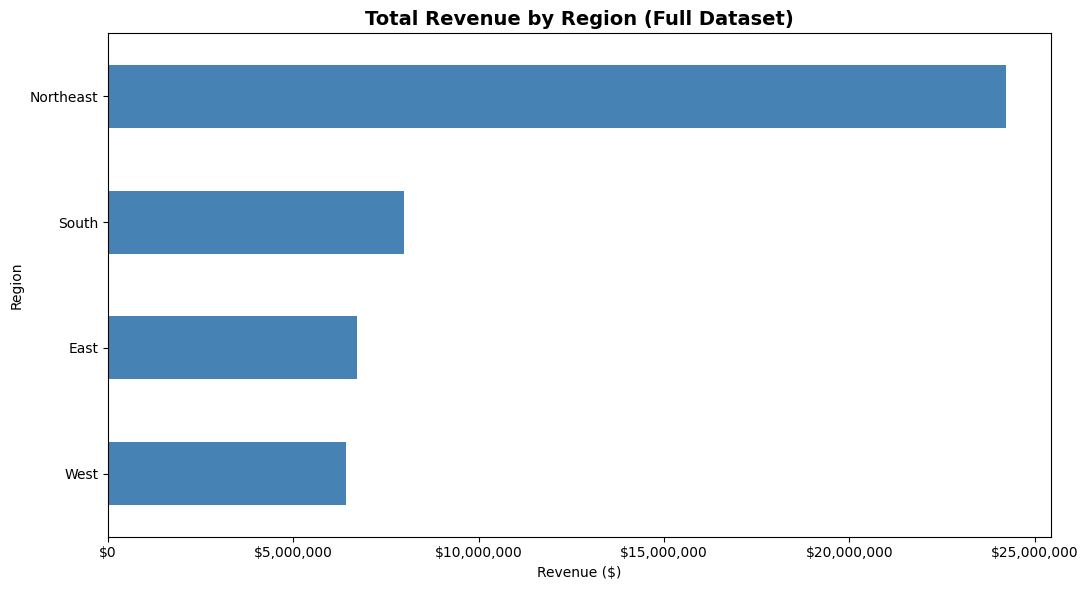

In [14]:
# Bonus Chart 1: Revenue by region
fig, ax = plt.subplots()
region_rev.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Total Revenue by Region (Full Dataset)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout(); plt.show()

In [15]:
# Q10: Total revenue and transaction count per subcategory in my territories.
# Which subcategories drive the most revenue?
# (Requires merging StoreSales -> Products -> ProductCategories.)

subcat = (terr.groupby('Subcategory')
          .agg(Total_Revenue=('Sale Amount', 'sum'),
               Transactions=('Sale Amount', 'count'))
          .sort_values('Total_Revenue', ascending=False).round(2))
subcat.head(15)

,Total_Revenue,Transactions
Subcategory,,
Laptops,6313615.36,4758
Tablets,2935610.81,3882
Software Download,1279880.00,4373
Business & Economics,501005.04,3087
Calculators,479476.98,1384
Headphones,478645.85,4100
Health Sciences,409412.98,2286
Social Sciences,389793.50,1675
Engineering & Technology,355365.40,2353


In [16]:
# Q11: Rewards members in my territories. Avg transaction value: rewards vs. non-rewards.
# (Requires merging StoreSales with customer_list on RewardsID = cust_id.)

terr_rewards = terr[terr['RewardsID'].notna()].copy()
terr_rewards['RewardsID'] = terr_rewards['RewardsID'].astype(int)
terr_members = terr_rewards.merge(customers[['cust_id', 'name']],
                                  left_on='RewardsID', right_on='cust_id', how='left')

n_members = terr_members['RewardsID'].nunique()
print("Distinct rewards members who purchased in my territories:", n_members)

avg_rewards = terr[terr['RewardsID'].notna()]['Sale Amount'].mean()
avg_non = terr[terr['RewardsID'].isna()]['Sale Amount'].mean()
print(f"\nAvg transaction — rewards members:     ${avg_rewards:,.2f}")
print(f"Avg transaction — non-rewards customers: ${avg_non:,.2f}")
print(f"Difference: ${avg_rewards - avg_non:,.2f}")

Distinct rewards members who purchased in my territories: 521

Avg transaction — rewards members:     $131.71
Avg transaction — non-rewards customers: $130.59
Difference: $1.12


In [17]:
# Q12: Top 10 rewards members by total spend across the full dataset. Transaction counts?

all_rewards = df[df['RewardsID'].notna()].copy()
all_rewards['RewardsID'] = all_rewards['RewardsID'].astype(int)
all_named = all_rewards.merge(customers[['cust_id', 'name']],
                              left_on='RewardsID', right_on='cust_id', how='left')

top10_members = (all_named.groupby(['RewardsID', 'name'])['Sale Amount']
                 .agg(Total_Spend='sum', Transactions='count')
                 .sort_values('Total_Spend', ascending=False).head(10).round(2))
top10_members

,,Total_Spend,Transactions
RewardsID,name,,
245,Gloria Mendoza,17534.76,79
180,Cole Brown,17392.38,91
74,Ben Chang,17320.93,80
47,Stanley H.,16473.72,75
375,C.J. Cregg,16466.96,81
280,Cal Abar,16387.39,81
242,Lorna Morello,15950.82,75
409,Gerri Kellman,15798.41,80
99,Trent Lane,15771.27,80


In [18]:
# Q13: Year-over-year revenue comparison for my territories. Trending up or down?

yoy = (terr.groupby(['Year', 'State'])['Sale Amount'].sum()
       .unstack('State').round(2))
print(yoy.to_string())
print("\nYear-over-year % change:")
print((yoy.pct_change() * 100).round(1).to_string())

State    Maryland  Massachusetts
Year                            
2022   2409967.70      863610.11
2023   2813693.20     1366498.43
2024   2821691.59     1371483.59
2025   3406262.60     2131664.14

Year-over-year % change:
State  Maryland  Massachusetts
Year                          
2022        NaN            NaN
2023       16.8           58.2
2024        0.3            0.4
2025       20.7           55.4


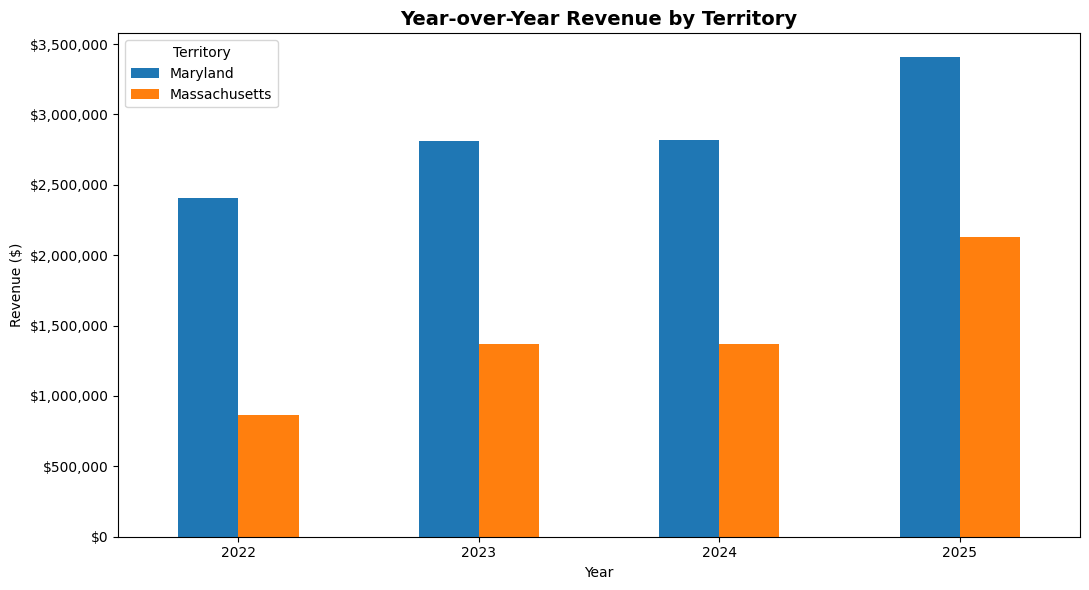

In [19]:
# Bonus Chart 2: YoY revenue by territory
fig, ax = plt.subplots()
yoy.plot(kind='bar', ax=ax)
ax.set_title('Year-over-Year Revenue by Territory', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(title='Territory'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [20]:
# Q14: Best and worst single month for each of my territories over the full period.

monthly = terr.groupby(['State', 'Month'])['Sale Amount'].sum()
for state in MY_STATES:
    s = monthly.loc[state]
    print(f"--- {state} ---")
    print(f"  BEST  month: {s.idxmax()}  =  ${s.max():,.2f}")
    print(f"  WORST month: {s.idxmin()}  =  ${s.min():,.2f}\n")

--- Maryland ---
  BEST  month: 2025-10  =  $359,699.69
  WORST month: 2022-09  =  $158,952.74

--- Massachusetts ---
  BEST  month: 2025-10  =  $277,382.19
  WORST month: 2022-09  =  $58,716.74



In [21]:
# Q15: Fit a linear regression to combined monthly revenue. Plot trend line. Up or down?

# Combined monthly revenue across both my territories
monthly_total = terr.groupby('Month')['Sale Amount'].sum().sort_index()
x = np.arange(len(monthly_total))             # month index 0,1,2,...
y = monthly_total.to_numpy()

# Fit a line: y = slope*x + intercept (NumPy polyfit, degree 1)
slope, intercept = np.polyfit(x, y, 1)
trend = slope * x + intercept
print(f"Slope: ${slope:,.2f} per month  ->  trend is {'UP' if slope > 0 else 'DOWN'}ward")
print(f"Projected change over the period: ${slope * len(x):,.2f}")

Slope: $4,694.85 per month  ->  trend is UPward
Projected change over the period: $225,353.03


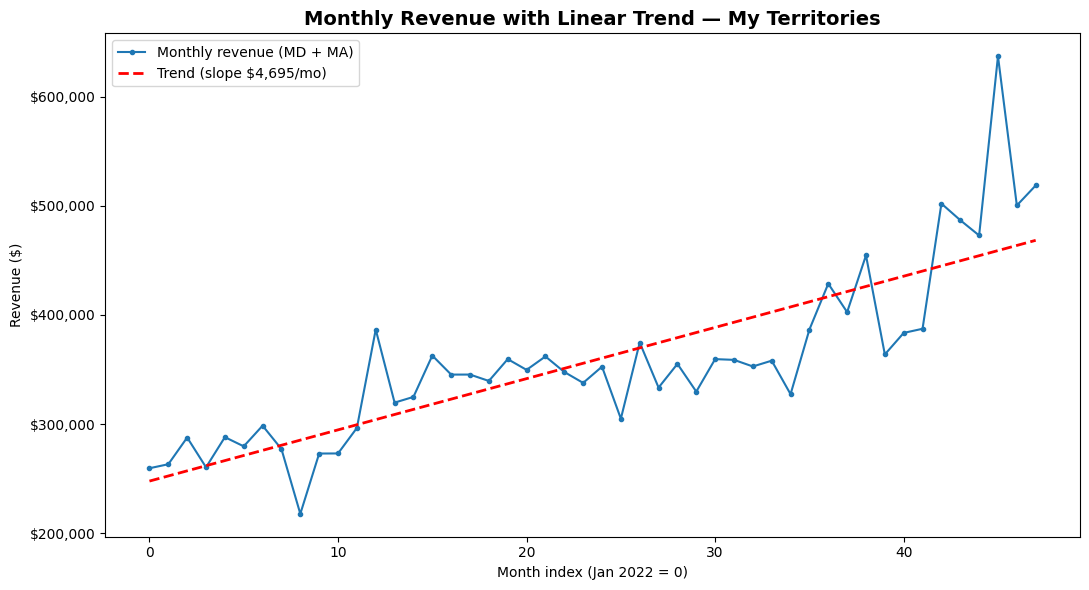

In [22]:
# Bonus Chart 3: monthly revenue with linear regression trend line
fig, ax = plt.subplots()
months = monthly_total.index.astype(str)
ax.plot(x, y, marker='o', markersize=3, label='Monthly revenue (MD + MA)')
ax.plot(x, trend, color='red', linewidth=2, linestyle='--',
        label=f'Trend (slope ${slope:,.0f}/mo)')
ax.set_title('Monthly Revenue with Linear Trend — My Territories', fontsize=14, fontweight='bold')
ax.set_xlabel('Month index (Jan 2022 = 0)'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(); plt.tight_layout(); plt.show()

In [23]:
# Bonus Summary
#
# All 15 appendix questions answered: filtering and sorting (Q1-3), NumPy aggregation
# (Q4-7), multi-table merges (Q8-12), and advanced YoY + linear regression (Q13-15),
# with 3 supporting Matplotlib charts.
#
# Themes reinforce the core notebook:
# - Technology & Accessories dominates revenue (Q6)
# - Maryland's revenue is heavily concentrated in North Harford (Q5)
# - Massachusetts has broad, even per-store spread with growing momentum (Q13)
# - Overall trend across both territories is UPWARD (Q15)